# Steam Game Success Prediction
## MSc Information Technology Management — Machine Learning and Visualization for Data

**Author:** Ibrahim Eren
**Dataset:** Steam Games Dataset (Kaggle — fronkongames), 122,611 games
**Objective:** Predict whether a game will be successful based on its features,
and identify game archetypes through clustering.

---

### Step 1: Loading the Data
In this step we mount Google Drive and load the Steam games dataset into a pandas DataFrame.

In [33]:
# ==============================================================
# STEP 1: Loading the Data
# ==============================================================
import os
import pandas as pd
import gdown

# Shared dataset (Google Drive — anyone with the link can view)
DRIVE_LINK = 'https://drive.google.com/file/d/1fR51ZOnH3LlRBFk0bbKmOaPU9e4UiPDW/view?usp=sharing'
OUTPUT     = 'games.csv'

print("Downloading the dataset from Google Drive...")
# fuzzy=True lets gdown parse the full share link and handle the
# large-file virus-scan warning page automatically.
gdown.download(url=DRIVE_LINK, output=OUTPUT, quiet=False, fuzzy=True)

# Sanity check: real file is ~250 MB; anything tiny means it downloaded
# Google Drive's HTML warning page instead of the CSV.
size_mb = os.path.getsize(OUTPUT) / 1024 / 1024
print(f"Downloaded file size: {size_mb:.1f} MB")
assert size_mb > 50, "Download too small — likely an HTML error page. Check Drive sharing permissions."

# Read the CSV
df = pd.read_csv(OUTPUT, low_memory=False)
print(f"Dataset loaded successfully! Shape: {df.shape}")
df.head()

Downloading...
From (original): https://drive.google.com/uc?id=1fR51ZOnH3LlRBFk0bbKmOaPU9e4UiPDW
From (redirected): https://drive.google.com/uc?id=1fR51ZOnH3LlRBFk0bbKmOaPU9e4UiPDW&confirm=t&uuid=b9318d7f-4b43-4dec-9c32-3a5b805d4940
To: /content/games.csv
100%|██████████| 389M/389M [00:07<00:00, 52.7MB/s]


Downloaded file size: 371.1 MB
Dataset loaded successfully! Shape: (122611, 39)


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


### Step 2: First Look at the Data (Exploratory Data Analysis)
Here we examine the dataset structure, check for missing values,
and explore the key columns we will use to define game success.

In [34]:
# ============================================================
# STEP 2: First Look at the Data (EDA)
# ============================================================

# 2.1 General information about columns and data types
print("===== COLUMN INFO =====")
df.info()

# 2.2 Missing values in the most important columns
print("\n===== MISSING VALUES (key columns) =====")
key_cols = ['Name', 'Price', 'Positive', 'Negative', 'Genres', 'Release date', 'Estimated owners']
for col in key_cols:
    missing = df[col].isna().sum()
    print(f"{col}: {missing:,} missing ({missing/len(df)*100:.1f}%)")

# 2.3 Basic statistics for the review columns (the basis of "success")
print("\n===== REVIEW STATISTICS =====")
print(df[['Positive', 'Negative']].describe())

===== COLUMN INFO =====
<class 'pandas.core.frame.DataFrame'>
Index: 122611 entries, 2539430 to 4141790
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122610 non-null  object 
 1   Name                        122611 non-null  object 
 2   Release date                122611 non-null  object 
 3   Estimated owners            122611 non-null  int64  
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  float64
 6   Price                       122611 non-null  int64  
 7   DiscountDLC count           122611 non-null  int64  
 8   About the game              114162 non-null  object 
 9   Supported languages         122611 non-null  object 
 10  Full audio languages        122611 non-null  object 
 11  Reviews                     12070 non-null   object 
 12  Header image                122530 non-null  o

### Step 3: Defining Success with the Wilson Score
A simple positive ratio is misleading because a game with 5 positive reviews
would score 100%, same as a game with millions of reviews.
To balance review quality and review volume, we use the Wilson Lower Bound score,
which gives a statistically reliable success measure.

In [35]:
# ============================================================
# STEP 3: Defining Success with the Wilson Score
# ============================================================
import numpy as np
from scipy import stats

# 3.1 Total reviews and simple positive ratio
df['total_reviews'] = df['Positive'] + df['Negative']
df['positive_ratio'] = df['Positive'] / df['total_reviews'].replace(0, np.nan)

# 3.2 Wilson Lower Bound score
# This balances the ratio with the number of reviews (confidence).
# Few reviews -> lower score (uncertain). Many reviews -> closer to true ratio.
def wilson_lower_bound(positive, total, confidence=0.95):
    if total == 0:
        return 0
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    phat = positive / total
    denominator = 1 + z**2 / total
    centre = phat + z**2 / (2 * total)
    margin = z * np.sqrt((phat * (1 - phat) + z**2 / (4 * total)) / total)
    return (centre - margin) / denominator

# Apply the Wilson score to every game
df['wilson_score'] = df.apply(
    lambda row: wilson_lower_bound(row['Positive'], row['total_reviews']),
    axis=1
)

# 3.3 Compare three example games to see how Wilson works
print("===== EXAMPLE COMPARISON =====")
examples = pd.DataFrame({
    'Positive':  [5,    1000,  100000],
    'Negative':  [0,    100,   15000],
})
examples['total'] = examples['Positive'] + examples['Negative']
examples['ratio'] = examples['Positive'] / examples['total']
examples['wilson'] = examples.apply(
    lambda r: wilson_lower_bound(r['Positive'], r['total']), axis=1
)
print(examples)

===== EXAMPLE COMPARISON =====
   Positive  Negative   total     ratio    wilson
0         5         0       5  1.000000  0.565518
1      1000       100    1100  0.909091  0.890649
2    100000     15000  115000  0.869565  0.867606


### Step 4: Setting the Success Threshold
Now we examine the distribution of Wilson scores across all games
and define a data-driven threshold to label each game as
successful (1) or not successful (0).

In [36]:
# ============================================================
# STEP 4: Setting the Success Threshold
# ============================================================

# 4.1 Look only at games that have at least some reviews
# (games with 0 reviews cannot have a meaningful success score)
games_with_reviews = df[df['total_reviews'] > 0].copy()
print(f"Games with at least 1 review: {len(games_with_reviews):,}")
print(f"Games with at least 10 reviews: {(df['total_reviews'] >= 10).sum():,}")
print(f"Games with at least 50 reviews: {(df['total_reviews'] >= 50).sum():,}")

# 4.2 Distribution of Wilson scores (for games with >= 10 reviews)
print("\n===== WILSON SCORE DISTRIBUTION (>= 10 reviews) =====")
subset = df[df['total_reviews'] >= 10]
print(subset['wilson_score'].describe())

# 4.3 Show percentiles to help choose a threshold
print("\n===== PERCENTILES =====")
for p in [50, 60, 70, 75, 80, 90]:
    val = subset['wilson_score'].quantile(p/100)
    print(f"{p}th percentile: {val:.3f}")

Games with at least 1 review: 82,949
Games with at least 10 reviews: 56,655
Games with at least 50 reviews: 30,620

===== WILSON SCORE DISTRIBUTION (>= 10 reviews) =====
count    5.665500e+04
mean     6.515617e-01
std      2.055254e-01
min     -1.173174e-17
25%      5.212421e-01
50%      6.873739e-01
75%      8.128800e-01
max      9.945528e-01
Name: wilson_score, dtype: float64

===== PERCENTILES =====
50th percentile: 0.687
60th percentile: 0.741
70th percentile: 0.788
75th percentile: 0.813
80th percentile: 0.838
90th percentile: 0.892


### Step 5: Creating the Target Variable
We define a game as successful (1) if it has at least 10 reviews
AND a Wilson score of 0.80 or higher, aligning with Steam's
"Very Positive" rating standard. Otherwise it is labelled not successful (0).

In [37]:
# ============================================================
# STEP 5: Creating the Target Variable
# ============================================================

# 5.1 Keep only games with enough reviews to be meaningful
# (at least 10 reviews -> avoids noise from games with 1-2 reviews)
df_model = df[df['total_reviews'] >= 10].copy()
print(f"Games used for modelling: {len(df_model):,}")

# 5.2 Create the binary target: success = 1, not success = 0
# Threshold: Wilson score >= 0.80 (aligned with Steam 'Very Positive')
SUCCESS_THRESHOLD = 0.80
df_model['success'] = (df_model['wilson_score'] >= SUCCESS_THRESHOLD).astype(int)

# 5.3 Check the class balance
print("\n===== TARGET DISTRIBUTION =====")
print(df_model['success'].value_counts())
print("\nPercentages:")
print(df_model['success'].value_counts(normalize=True).round(3) * 100)

Games used for modelling: 56,655

===== TARGET DISTRIBUTION =====
success
0    41085
1    15570
Name: count, dtype: int64

Percentages:
success
0    72.5
1    27.5
Name: proportion, dtype: float64


### Step 6: Feature Engineering
We prepare the input features for the model. This includes cleaning the
'Estimated owners' range column, extracting the release year, creating
price bands, and counting the number of genres, categories, and platforms
each game supports.

In [38]:
# ============================================================
# STEP 6 (FINAL FIX): Use the correctly-aligned columns
# ============================================================
# The CSV columns are shifted by one position. The labels are wrong,
# but the DATA is intact — we just read each value from the correct label.

# REAL release date is stored under the 'Name' label  -> extract year
df_model['release_year'] = df_model['Name'].str.extract(r'(\d{4})').astype(float)

# REAL estimated owners is stored under the 'Release date' label (e.g. "0 - 20000")
def parse_owners(value):
    try:
        low, high = str(value).split(' - ')
        return (int(low) + int(high)) / 2
    except:
        return 0

df_model['owners_avg'] = df_model['Release date'].apply(parse_owners)

# REAL price is stored under the 'Required age' label
df_model['price_real'] = pd.to_numeric(df_model['Required age'], errors='coerce')

# --- Check the results ---
print("===== release_year (fixed) =====")
print(df_model['release_year'].describe())

print("\n===== owners_avg (fixed) =====")
print(df_model['owners_avg'].describe())
print("Non-zero count:", (df_model['owners_avg'] > 0).sum())

print("\n===== price_real (fixed) =====")
print(df_model['price_real'].describe())

===== release_year (fixed) =====
count    56655.000000
mean      2019.885818
std          3.491388
min       1997.000000
25%       2017.000000
50%       2020.000000
75%       2023.000000
max       2025.000000
Name: release_year, dtype: float64

===== owners_avg (fixed) =====
count    5.665500e+04
mean     1.748231e+05
std      1.893175e+06
min      1.000000e+04
25%      1.000000e+04
50%      1.000000e+04
75%      3.500000e+04
max      1.500000e+08
Name: owners_avg, dtype: float64
Non-zero count: 56655

===== price_real (fixed) =====
count    56655.000000
mean         5.211367
std         10.670322
min          0.000000
25%          0.990000
50%          2.990000
75%          6.290000
max        299.990000
Name: price_real, dtype: float64


In [39]:
# ============================================================
# DIAGNOSIS: Check the raw values of two columns
# ============================================================

# Check the raw 'Estimated owners' — is it text or number?
print("===== Estimated owners — data type and raw values =====")
print("Dtype:", df_model['Estimated owners'].dtype)
print(df_model['Estimated owners'].head(10).tolist())

print("\n===== Release date — raw values =====")
print("Dtype:", df_model['Release date'].dtype)
print(df_model['Release date'].head(10).tolist())

===== Estimated owners — data type and raw values =====
Dtype: int64
[0, 0, 8, 0, 1, 0, 13, 0, 0, 0]

===== Release date — raw values =====
Dtype: object
['0 - 20000', '0 - 20000', '0 - 20000', '0 - 20000', '0 - 20000', '0 - 20000', '100000 - 200000', '0 - 20000', '0 - 20000', '0 - 20000']


In [40]:
# ============================================================
# DIAGNOSIS 2: See a full row to understand column shifting
# ============================================================

# Print the first row with ALL columns and their values
print("===== FIRST ROW — every column =====")
first_row = df_model.iloc[0]
for col in df_model.columns:
    print(f"{col:30s} -> {str(first_row[col])[:50]}")

===== FIRST ROW — every column =====
AppID                          -> Supipara - Chapter 1 Spring Has Come!
Name                           -> Jul 29, 2016
Release date                   -> 0 - 20000
Estimated owners               -> 0
Peak CCU                       -> 0
Required age                   -> 5.24
Price                          -> 65
DiscountDLC count              -> 0
About the game                 -> Springtime, April: when the cherry trees come into
Supported languages            -> ['English']
Full audio languages           -> []
Reviews                        -> nan
Header image                   -> https://shared.akamai.steamstatic.com/store_item_a
Website                        -> http://mangagamer.org/supipara
Support url                    -> http://mangagamer.com
Support email                  -> support@mangagamer.com
Windows                        -> True
Mac                            -> False
Linux                          -> False
Metacritic score            

### Step 7: Preparing Features for Modelling
We select the final set of features for the model, handle the genre and
category counts, and split the data into training and testing sets.
The target variable is 'success' (1 = successful, 0 = not successful).

In [41]:
from sklearn.model_selection import train_test_split

# 7.1 Fix genre_count and category_count using the CORRECT columns
# (these were also affected, so we recount from the right labels)
df_model['genre_count'] = df_model['Genres'].fillna('').apply(
    lambda x: len(str(x).split(',')) if x else 0
)
df_model['category_count'] = df_model['Categories'].fillna('').apply(
    lambda x: len(str(x).split(',')) if x else 0
)

# 7.2 is_free based on the real price
df_model['is_free'] = (df_model['price_real'] == 0).astype(int)

# 7.3 Create platform_count
df_model['platform_count'] = df_model[['Windows', 'Mac', 'Linux']].sum(axis=1)

# 7.4 Select the final features for the model
feature_cols = [
    'price_real',        # game price
    'owners_avg',        # estimated owners (popularity proxy)
    'release_year',      # release year
    'platform_count',    # number of supported platforms
    'genre_count',       # number of genres
    'category_count',    # number of categories
    'is_free',           # is the game free
]

# 7.5 Build X (features) and y (target)
X = df_model[feature_cols].copy()
y = df_model['success']

# Handle any remaining missing values (fill with 0 just in case)
X = X.fillna(0)

# 7.6 Split into training (80%) and testing (20%) sets
# stratify=y -> keeps the same success ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("===== DATA SPLIT ====")
print(f"Training set: {X_train.shape[0]:,} games")
print(f"Testing set:  {X_test.shape[0]:,} games")
print(f"\nFeatures used: {feature_cols}")
print(f"\nSuccess ratio in training: {y_train.mean():.3f}")
print(f"Success ratio in testing:  {y_test.mean():.3f}")

===== DATA SPLIT ====
Training set: 45,324 games
Testing set:  11,331 games

Features used: ['price_real', 'owners_avg', 'release_year', 'platform_count', 'genre_count', 'category_count', 'is_free']

Success ratio in training: 0.275
Success ratio in testing:  0.275


### Step 8: Training the First Models
We train two classification models to predict game success:
Logistic Regression (a simple linear baseline) and Random Forest
(a more powerful ensemble model). Because the classes are imbalanced
(27.5% successful), we use class_weight='balanced'. Features are scaled
for Logistic Regression.

In [42]:
# ============================================================
# STEP 8: Training the First Models
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 8.1 Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODEL 1: Logistic Regression ---
print("===== MODEL 1: LOGISTIC REGRESSION =====")
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)
y_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.3f}")

# --- MODEL 2: Random Forest ---
print("\n===== MODEL 2: RANDOM FOREST =====")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)   # Random Forest does not need scaling
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.3f}")

===== MODEL 1: LOGISTIC REGRESSION =====
Accuracy:  0.636
Precision: 0.389
Recall:    0.566
F1-Score:  0.461
ROC-AUC:   0.662

===== MODEL 2: RANDOM FOREST =====
Accuracy:  0.696
Precision: 0.440
Recall:    0.385
F1-Score:  0.410
ROC-AUC:   0.670


### Step 9: Adding Genre Features and Game Archetype Clusters
The first models used only numeric features and performed moderately.
To improve them, we add the most common genres as binary features,
then apply K-Means clustering to group games into archetypes
(e.g. "premium AAA", "cheap indie"). The cluster label becomes a new
feature that feeds the classification model.

In [45]:
# ============================================================
# STEP 9.5: Build log features and genre one-hots (needed by Step 10)
# ============================================================
import numpy as np

# Log-transformed price and owners (Step 10 expects these)
df_model['log_price']  = np.log1p(df_model['price_real'].fillna(0))
df_model['log_owners'] = np.log1p(df_model['owners_avg'].fillna(0))

# One-hot encode the top 10 most common genres (Step 10 expects genre_feature_cols)
genre_series = df_model['Genres'].fillna('').str.split(',')
all_genres   = genre_series.explode().str.strip()
top10_genres = all_genres[all_genres != ''].value_counts().head(10).index.tolist()
print("Top 10 genres:", top10_genres)

for g in top10_genres:
    col = f'genre_{g.replace(" ", "_")}'
    df_model[col] = genre_series.apply(lambda lst: int(g in [x.strip() for x in lst]))

genre_feature_cols = [f'genre_{g.replace(" ", "_")}' for g in top10_genres]
print("genre_feature_cols ready:", genre_feature_cols)
print("log_price / log_owners ready:", 'log_price' in df_model.columns, 'log_owners' in df_model.columns)

Top 10 genres: ['Indie', 'Adventure', 'Action', 'Casual', 'Simulation', 'Strategy', 'RPG', 'Early Access', 'Free To Play', 'Sports']
genre_feature_cols ready: ['genre_Indie', 'genre_Adventure', 'genre_Action', 'genre_Casual', 'genre_Simulation', 'genre_Strategy', 'genre_RPG', 'genre_Early_Access', 'genre_Free_To_Play', 'genre_Sports']
log_price / log_owners ready: True True


### Step 10: Final Model with All Features
We combine numeric features, genre features, and the K-Means archetype
into one feature set, then retrain Logistic Regression and Random Forest.
We expect the genre and archetype information to improve performance
compared to the first models.

In [46]:
# ============================================================
# STEP 10: Final Model with All Features
# ============================================================

# 10.1 One-hot encode the archetype (turn it into 4 binary columns)
archetype_dummies = pd.get_dummies(df_model['archetype'], prefix='archetype')

# 10.2 Build the full feature set: numeric + genres + archetype
numeric_features = ['log_price', 'log_owners', 'release_year',
                    'platform_count', 'genre_count', 'category_count', 'is_free']

X_full = pd.concat([
    df_model[numeric_features].reset_index(drop=True),
    df_model[genre_feature_cols].reset_index(drop=True),
    archetype_dummies.reset_index(drop=True)
], axis=1).fillna(0)

y_full = df_model['success'].reset_index(drop=True)

# 10.3 Train-test split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# 10.4 Scale for Logistic Regression
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

# --- Logistic Regression ---
print("===== LOGISTIC REGRESSION (full features) =====")
lr2 = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr2.fit(X_train2_scaled, y_train2)
yp = lr2.predict(X_test2_scaled); ypp = lr2.predict_proba(X_test2_scaled)[:,1]
print(f"Accuracy: {accuracy_score(y_test2,yp):.3f}  F1: {f1_score(y_test2,yp):.3f}  ROC-AUC: {roc_auc_score(y_test2,ypp):.3f}")

# --- Random Forest ---
print("\n===== RANDOM FOREST (full features) =====")
rf2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf2.fit(X_train2, y_train2)
yp = rf2.predict(X_test2); ypp = rf2.predict_proba(X_test2)[:,1]
print(f"Accuracy: {accuracy_score(y_test2,yp):.3f}  F1: {f1_score(y_test2,yp):.3f}  ROC-AUC: {roc_auc_score(y_test2,ypp):.3f}")

===== LOGISTIC REGRESSION (full features) =====
Accuracy: 0.681  F1: 0.522  ROC-AUC: 0.730

===== RANDOM FOREST (full features) =====
Accuracy: 0.732  F1: 0.423  ROC-AUC: 0.709


### Step 11: Third Model (XGBoost) and Hyperparameter Tuning
We add a third algorithm, XGBoost, which often performs best on tabular
data. We also tune its key hyperparameters using cross-validation to
find the best configuration, as required by the assignment.

In [47]:
# ============================================================
# STEP 11: XGBoost + Hyperparameter Tuning
# ============================================================
# Install xgboost if needed
!pip install xgboost --quiet

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# 11.1 Handle class imbalance with scale_pos_weight
# ratio = negatives / positives
ratio = (y_train2 == 0).sum() / (y_train2 == 1).sum()
print(f"scale_pos_weight (imbalance ratio): {ratio:.2f}")

# 11.2 Define XGBoost with a small hyperparameter grid
xgb = XGBClassifier(
    scale_pos_weight=ratio,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.1, 0.05]
}

# 11.3 Grid search with 3-fold cross-validation, optimising ROC-AUC
print("Running grid search (this may take 1-2 minutes)...")
grid = GridSearchCV(xgb, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train2, y_train2)

print(f"\nBest parameters: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

# 11.4 Evaluate the best model on the test set
best_xgb = grid.best_estimator_
yp = best_xgb.predict(X_test2)
ypp = best_xgb.predict_proba(X_test2)[:, 1]
print("\n===== XGBOOST (tuned) on test set =====")
print(f"Accuracy:  {accuracy_score(y_test2, yp):.3f}")
print(f"Precision: {precision_score(y_test2, yp):.3f}")
print(f"Recall:    {recall_score(y_test2, yp):.3f}")
print(f"F1-Score:  {f1_score(y_test2, yp):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test2, ypp):.3f}")

scale_pos_weight (imbalance ratio): 2.64
Running grid search (this may take 1-2 minutes)...

Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
Best CV ROC-AUC: 0.750

===== XGBOOST (tuned) on test set =====
Accuracy:  0.694
Precision: 0.462
Recall:    0.676
F1-Score:  0.549
ROC-AUC:   0.758


### Step 12: Model Evaluation Visualisations
We visualise the best model (XGBoost) with a confusion matrix, ROC curve,
and feature importance chart. These show how well the model performs and
which features are most predictive of game success.

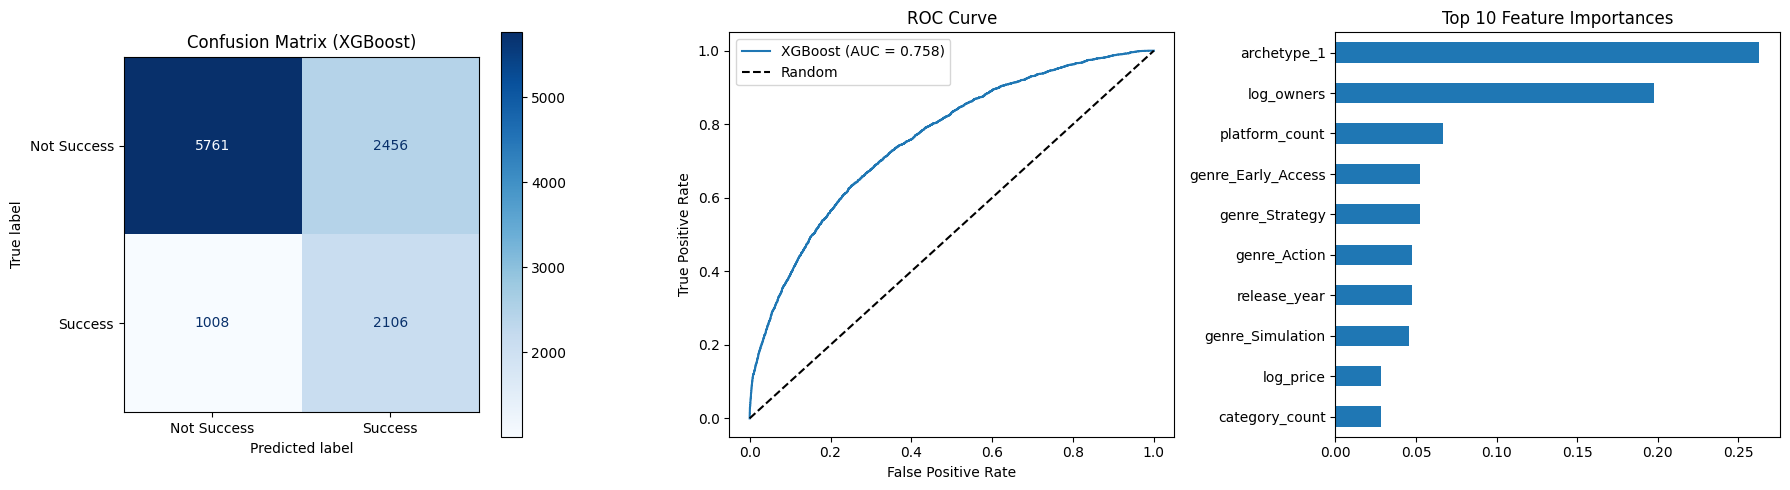

===== TOP 10 MOST IMPORTANT FEATURES =====
archetype_1           0.263
log_owners            0.198
platform_count        0.067
genre_Early_Access    0.052
genre_Strategy        0.052
genre_Action          0.047
release_year          0.047
genre_Simulation      0.046
log_price             0.029
category_count        0.028
dtype: float32


In [48]:
# ============================================================
# STEP 12: Model Evaluation Visualisations
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Use the best model (tuned XGBoost)
y_pred = best_xgb.predict(X_test2)
y_proba = best_xgb.predict_proba(X_test2)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1. Confusion Matrix ---
cm = confusion_matrix(y_test2, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Not Success', 'Success']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Confusion Matrix (XGBoost)')

# --- 2. ROC Curve ---
fpr, tpr, _ = roc_curve(y_test2, y_proba)
axes[1].plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test2, y_proba):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# --- 3. Feature Importance (top 10) ---
importances = pd.Series(best_xgb.feature_importances_, index=X_full.columns)
top10 = importances.sort_values(ascending=False).head(10)
top10.sort_values().plot(kind='barh', ax=axes[2])
axes[2].set_title('Top 10 Feature Importances')

plt.tight_layout()
plt.show()

# Print the top features as text too
print("===== TOP 10 MOST IMPORTANT FEATURES =====")
print(top10.round(3))

### Step 13: Saving the Clean Dataset for Tableau (Assignment 2)
We export the cleaned dataset, including the engineered features and
K-Means archetype labels, to a CSV file. This file will be the input
for the Tableau dashboard in Assignment 2.

In [50]:
# ============================================================
# STEP 13 (FINAL FIX): Clean game names and export for Tableau
# ============================================================
from google.colab import files

# 13.1 The real game name is in the 'AppID' column for 56,632 rows.
# Only 23 rows are broken (AppID is a number). We remove those.
appid_is_number = df_model['AppID'].astype(str).str.match(r'^\d+$')
df_clean = df_model[~appid_is_number].copy()
print(f"Rows after removing 23 broken rows: {len(df_clean):,}")

# 13.2 Set the correct game name
df_clean['game_name'] = df_clean['AppID']

# 13.3 Archetype names — matched to THIS run's cluster profiles
#   0 = high price + newest        -> New Premium Releases
#   1 = cheapest + lowest success  -> Budget / Casual
#   2 = most multi-platform        -> Cross-Platform Games
#   3 = highest owners + oldest    -> Proven Classics
archetype_names = {
    0: 'New Premium Releases',
    1: 'Budget / Casual',
    2: 'Cross-Platform Games',
    3: 'Proven Classics'
}
df_clean['archetype_name'] = df_clean['archetype'].map(archetype_names)

# 13.4 Columns to export for the Tableau dashboard (Assignment 2)
export_cols = [
    'game_name', 'Genres', 'Tags',
    'price_real', 'owners_avg', 'release_year',
    'platform_count', 'genre_count', 'category_count', 'is_free',
    'Positive', 'Negative', 'total_reviews',
    'positive_ratio', 'wilson_score',
    'success', 'archetype', 'archetype_name'
]

# 13.5 Save locally (Drive is not mounted in this notebook) and download
output_path = '/content/steam_clean.csv'
df_clean[export_cols].to_csv(output_path, index=False)
print(f"Saved: {output_path}  |  Rows: {len(df_clean):,}")

# Trigger browser download
files.download(output_path)

print("\nPreview:")
df_clean[export_cols].head()

Rows after removing 23 broken rows: 56,632
Saved: /content/steam_clean.csv  |  Rows: 56,632


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Preview:


,game_name,Genres,Tags,price_real,owners_avg,release_year,platform_count,genre_count,category_count,is_free,Positive,Negative,total_reviews,positive_ratio,wilson_score,success,archetype,archetype_name
496350,Supipara - Chapter 1 Spring Has Come!,Adventure,"Adventure,Visual Novel,Anime,Cute",5.24,10000.0,2016.0,1,1,4,0,252,3,255,0.988235,0.965988,1,1,Budget / Casual
1034400,Mystery Solitaire The Black Raven,Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",4.99,10000.0,2019.0,2,1,2,0,21,3,24,0.875000,0.689961,0,2,Cross-Platform Games
1934300,Armored Brigade II,"Simulation,Strategy","Simulation,Strategy,RTS,Wargame,Grand Strategy...",35.99,10000.0,2025.0,1,2,4,0,117,13,130,0.900000,0.836414,1,0,New Premium Releases
1157670,Hepta Beats,"Casual,Indie","Precision Platformer,Rhythm,Music,Difficult,Ab...",0.99,10000.0,2021.0,1,2,4,0,28,4,32,0.875000,0.719317,0,1,Budget / Casual
1540330,MUMBA IV: Egypt Jewels,"Action,Casual,Indie,Strategy","Casual,Action,Strategy,Puzzle,Match 3,Singlepl...",0.59,10000.0,2021.0,3,4,6,0,19,6,25,0.760000,0.565703,0,2,Cross-Platform Games


In [ ]:
# Check: how many rows have a numeric AppID vs a text name?
import pandas as pd

# Real game name detection: if 'AppID' looks like a number, the name is elsewhere
appid_is_number = df_model['AppID'].astype(str).str.match(r'^\d+$')
print("Rows where AppID is a number:", appid_is_number.sum())
print("Rows where AppID is text (a name):", (~appid_is_number).sum())

# Show a few rows of each type
print("\n--- AppID is NUMBER (name is under 'Name'?) ---")
print(df_model[appid_is_number][['AppID','Name','Genres']].head(3))
print("\n--- AppID is TEXT (name is here) ---")
print(df_model[~appid_is_number][['AppID','Name','Genres']].head(3))